# 📊 Exploración y visualización de datos

## 1. Cereals
### 1.1 Maize



In [ ]:
ds = xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\rice\yield_1984.nc4", engine="netcdf4")


In [74]:
# ==== LIBRERÍAS NECESARIAS ====
import os
import glob
import dask
import dask.array as da
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==== RUTAS PRINCIPALES ====
path_cereals = r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128"
path_olr     = r"C:\Users\paola\Tesis\01_Data\OLR\olr-monthly_v02r07_197901_202507.nc"
path_oni     = r"C:\Users\paola\Tesis\01_Data\ONI\ONI.txt"
path_rmm     = r"C:\Users\paola\Tesis\01_Data\RMM\romi.cpcolr.1x-RMM.txt"
path_sst     = r"C:\Users\paola\Tesis\01_Data\SST"

# ==== ARCHIVOS SST ====
# Todos los .nc dentro de la carpeta SST (1981–2025)
sst_files = sorted(glob.glob(os.path.join(path_sst, "sst.day.mean.*.nc")))

# ==== CARGA CON DASK ====
# Abrir todos los archivos SST como un único dataset con Dask
sst_ds = xr.open_mfdataset(
    sst_files,
    combine="by_coords",
    parallel=True,
    chunks={"time": 100}  # Ajusta el tamaño del chunk según tu RAM
)

print(sst_ds)


<xarray.Dataset> Size: 67GB
Dimensions:  (time: 16095, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 129kB 1981-09-01 1981-09-02 ... 2025-09-24
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 67GB dask.array<chunksize=(100, 720, 1440), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.5
    title:          NOAA High-resolution Blended Analysis: Daily Values using...
    institution:    NOAA/NCDC
    source:         NOAA/NCDC  ftp://eclipse.ncdc.noaa.gov/pub/OI-daily-v2/
    history:        Thu Aug 24 13:34:17 2017: ncatted -O -a References,global...
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...


<xarray.Dataset> Size: 37MB
Dimensions:  (time: 36, lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Dimensions without coordinates: time
Data variables:
    var      (time, lat, lon) float32 37MB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>


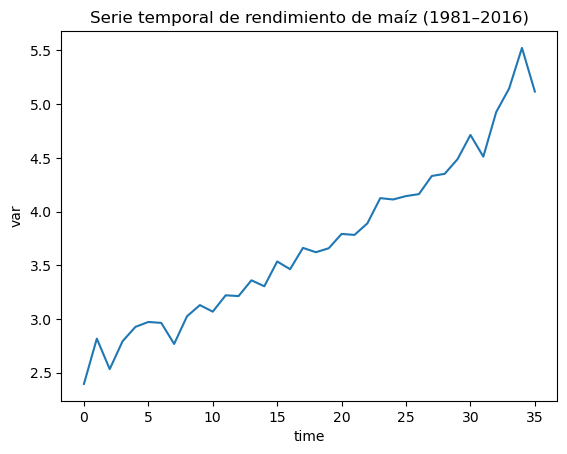

In [80]:
# Ruta de los archivos de maíz
path_maize = r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\maize"

# Listar todos los archivos nc4 de la carpeta
maize_files = sorted(glob.glob(path_maize + r"\yield_*.nc4"))

# Abrir todos en un solo dataset con Dask
maize_ds = xr.open_mfdataset(maize_files, combine="nested", concat_dim="time",
                             engine="h5netcdf", parallel=True, chunks={"lat":100, "lon":100})

print(maize_ds)

# Ejemplo: promedio global de rendimientos en el tiempo
maize_ds["var"].mean(dim=["lat", "lon"]).plot()
plt.title("Serie temporal de rendimiento de maíz (1981–2016)")
plt.show()

In [79]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (lon: 720, lat: 360)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    var      (lat, lon) float32 1MB ...

In [37]:
xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\rice\yield_1984.nc4")

<xarray.Dataset> Size: 1MB
Dimensions:  (lon: 720, lat: 360)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    var      (lat, lon) float32 1MB ...

In [38]:
rice1984=xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\rice\yield_1984.nc4")


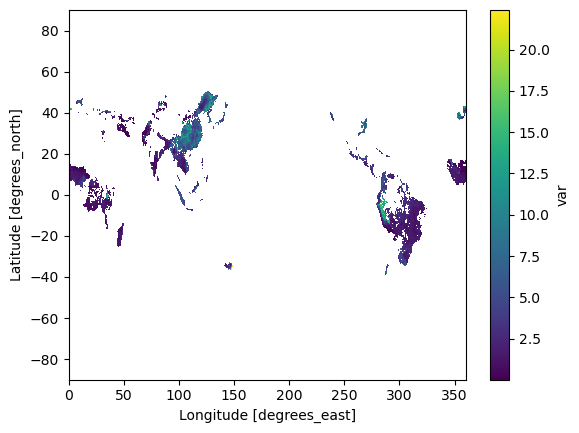

In [42]:
rice1984.get("var").plot()

In [44]:
SST=xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\SST\sst.day.mean.1988.nc")

In [45]:
SST

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 366, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1988-01-01 1988-01-02 ... 1988-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA High-resolution Blended Analysis: Daily Values using...
    institution:    NOAA/NCDC
    source:         NOAA/NCDC  ftp://eclipse.ncdc.noaa.gov/pub/OI-daily-v2/
    history:        Thu Aug 24 13:38:49 2017: ncatted -O -a References,global...
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

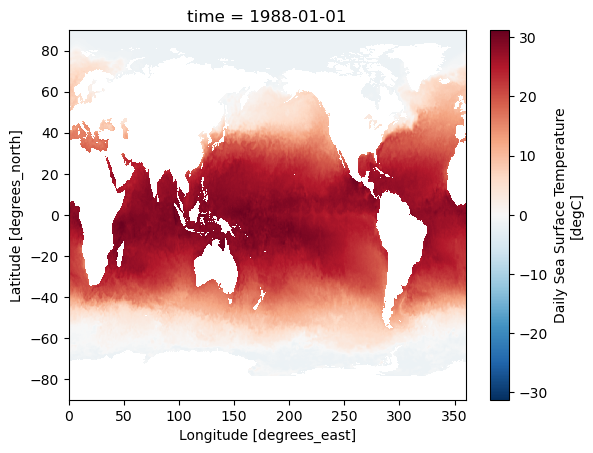

In [53]:
#SST.sst.mean(dim="time").plot()
SST.sst[0,:,:].plot()


In [48]:
np.diff(SST.lon.values)

array([0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25], dtype=float32)

In [54]:
rice1984.var[0,:,:].plot()

TypeError: 'method' object is not subscriptable

In [55]:
OLR=xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\OLR\OLR-Daily_v02r00-preliminary_s20250101_latest.nc")

In [56]:
OLR

<xarray.Dataset> Size: 69MB
Dimensions:      (time: 266, lat: 180, lon: 360, bnds: 2)
Coordinates:
  * lon          (lon) float32 1kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat          (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time         (time) datetime64[ns] 2kB 2025-01-01T12:00:00 ... 2025-09-23...
Dimensions without coordinates: bnds
Data variables:
    olr          (time, lat, lon) float32 69MB ...
    lon_bounds   (lon, bnds) float32 3kB ...
    lat_bounds   (lat, bnds) float32 1kB ...
    time_bounds  (time, bnds) datetime64[ns] 4kB ...
Attributes: (12/46)
    conventions:                CF-1.6, ACDD-1.3
    title:                      OLR-Daily CDR Product Ver02Rev00
    source:                     NOAA Archive of HIRS L1B data from TIROS-N Se...
    reference:                  doi:10.1175/2007JTECHA989.1  doi:10.1175/1520...
    history:                    2025-09-25T16:15:47Z - time period updated wi...
    comment:                    ICDR
    ...                         ...
    software_version_id:        Ver02Rev00
    Metadata_Link:              gov.noaa.ncdc:C00875
    product_version:            Ver02Rev00-preliminary
    platform:                   TIROS-N > Television Infrared Observation Sat...
    sensor:                     HIRS-2 > High Resolution Infra-red Sounder/2,...
    spatial_resolution:         1.0 by 1.0 degree equal angle

In [58]:
OLR.olr.mean.

<xarray.DataArray 'olr' (time: 266, lat: 180, lon: 360)> Size: 69MB
[17236800 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * time     (time) datetime64[ns] 2kB 2025-01-01T12:00:00 ... 2025-09-23T12:...
Attributes:
    long_name:      NOAA Climate Data Record of Daily Mean Upward Longwave Fl...
    standard_name:  toa_outgoing_longwave_flux
    units:          W m-2
    cell_methods:   time: mean area: mean
    valid_min:      50.0
    valid_max:      500.0

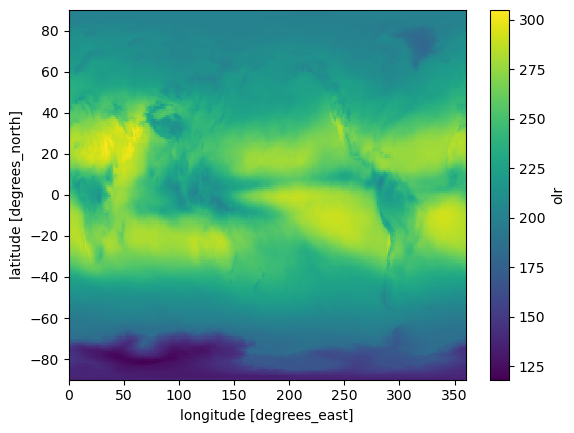

In [59]:
OLR.olr.mean(dim="time").plot()

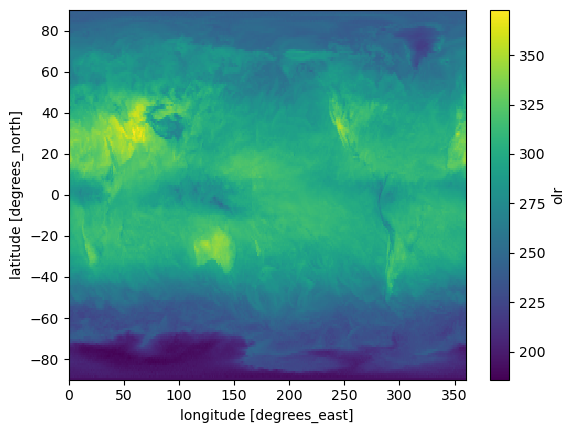

In [62]:
OLR.olr.max(dim="time").plot()

In [64]:
OLR.olr.max()

<xarray.DataArray 'olr' ()> Size: 4B
array(372.84402, dtype=float32)

<xarray.Dataset> Size: 23MB
Dimensions:      (lon: 144, time: 559, bounds_dim: 2, lat: 72)
Coordinates:
  * lon          (lon) float32 576B 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time         (time) datetime64[ns] 4kB 1979-01-16T12:00:00 ... 2025-07-16...
  * lat          (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Dimensions without coordinates: bounds_dim
Data variables:
    time_bounds  (time, bounds_dim) datetime64[ns] 9kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    olr          (time, lat, lon) float32 23MB dask.array<chunksize=(12, 72, 144), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      OLR-Monthly CDR Product Ver02Rev07
    source:                     NOAA Archive of HIRS L1B data from TIROS-N Se...
    reference:                  doi:10.1175/2007JTECHA989.1  doi:10.1175/1520...
    history:                    2025-08-04T11:06:55Z - time period updated wi...
    comment:      

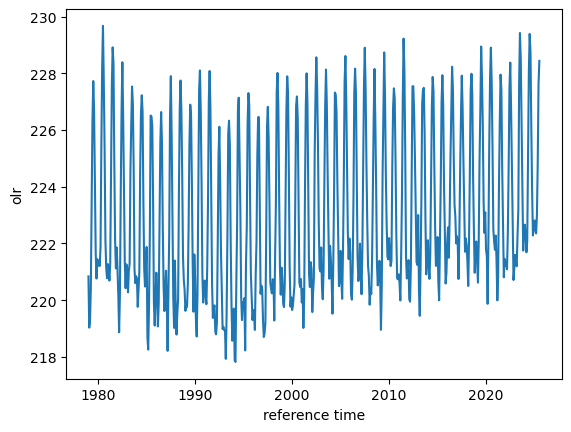

In [67]:
import xarray as xr

# Ruta del archivo
file = r"C:\Users\paola\Tesis\01_Data\OLR\olr-monthly_v02r07_197901_202507.nc"

# 1. Abrir con Dask (xarray lo usa por defecto si el archivo es grande)
ds = xr.open_dataset(file, chunks={"time": 12})  
# 👉 aquí le decimos que divida en "chunks" de 12 meses (1 año por bloque)

# 2. Explorar estructura
print(ds)

# 3. Variables disponibles
print("\nVariables:", list(ds.data_vars))

# 4. Ver metadatos de la variable principal (ejemplo: 'olr')
print(ds["olr"])

# 5. Calcular la media global (se ejecuta en paralelo con Dask)
global_mean = ds["olr"].mean(dim=["lat", "lon"])
print(global_mean)

# 6. Si quieres traerlo a memoria (¡cuidado con RAM!)
global_mean = global_mean.compute()

# 7. Graficar serie temporal
global_mean.plot()


In [68]:
ds

<xarray.Dataset> Size: 23MB
Dimensions:      (lon: 144, time: 559, bounds_dim: 2, lat: 72)
Coordinates:
  * lon          (lon) float32 576B 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time         (time) datetime64[ns] 4kB 1979-01-16T12:00:00 ... 2025-07-16...
  * lat          (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Dimensions without coordinates: bounds_dim
Data variables:
    time_bounds  (time, bounds_dim) datetime64[ns] 9kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    olr          (time, lat, lon) float32 23MB dask.array<chunksize=(12, 72, 144), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      OLR-Monthly CDR Product Ver02Rev07
    source:                     NOAA Archive of HIRS L1B data from TIROS-N Se...
    reference:                  doi:10.1175/2007JTECHA989.1  doi:10.1175/1520...
    history:                    2025-08-04T11:06:55Z - time period updated wi...
    comment:                    transitional update
    ...                         ...
    metadata_link:              https://doi.org/10.7289/V5W37TKD
    product_version:            Ver02Rev07
    platform:                   TIROS-N > Television Infrared Observation Sat...
    instrument:                 HIRS-2 > High Resolution Infra-red Sounder/2,...
    spatial_resolution:         2.5 by 2.5 degree equal angle
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...

In [69]:
ds.olr

<xarray.DataArray 'olr' (time: 559, lat: 72, lon: 144)> Size: 23MB
dask.array<open_dataset-olr, shape=(559, 72, 144), dtype=float32, chunksize=(12, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time     (time) datetime64[ns] 4kB 1979-01-16T12:00:00 ... 2025-07-16T12:...
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Attributes:
    long_name:      NOAA Climate Data Record of Monthly Mean Upward Longwave ...
    standard_name:  toa_outgoing_longwave_flux
    units:          W m-2
    cell_methods:   time: mean area: mean
    valid_min:      50.0
    valid_max:      500.0

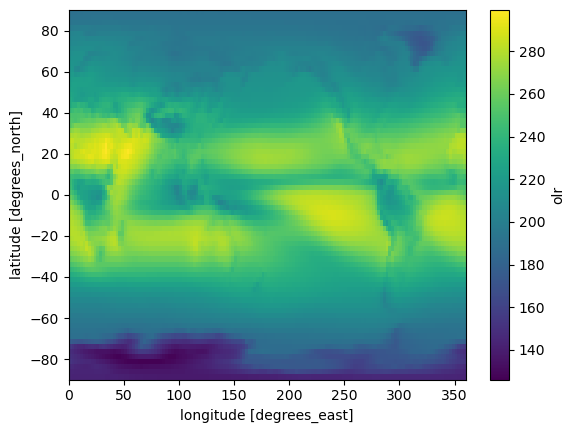

In [72]:
ds.olr.mean(dim="time").compute().plot()

